# **Project Title: Loan Approval Prediction**



>[Project Title: Loan Approval Prediction](#scrollTo=QdQDfKPslYs5)

>[Data Handling & Preparation (PREPROCESSING) bold text](#scrollTo=D8T3sa57GFW8)

>>[LIBRARIES](#scrollTo=QsXZ4zewfCie)

>>[Loading & Exploring data](#scrollTo=_3aLb73kemE_)

>>[Fixing the dependents column](#scrollTo=WbPvL2K-ftUm)

>>[Handling missing values](#scrollTo=eHxVW_Ole4Xn)

>>>[Numerical columns:](#scrollTo=3U2OgDOeDhiA)

>>>[Categorical columns:](#scrollTo=bHJJXMDofACh)

>>[Label Encoding](#scrollTo=J47TCnOfg6bY)

>[Exploratory Data Analysis (EDA)](#scrollTo=5VXUTwR-eMeg)

>>[Loan Status Distribution](#scrollTo=UwBgG2NJ_HZj)

>>[Credit Historty](#scrollTo=bD1UhlN_coJF)

>>[Detects Outliers](#scrollTo=qiXJ5BOpeEk6)

>>>[ApplicantIncome](#scrollTo=_NTP6A23k8CZ)

>>>[LoanAmount](#scrollTo=8M3tnImTlDD2)

>>>[TotalIncome](#scrollTo=_EDdUxe8lR_0)

>>[Correlation](#scrollTo=HACjk4Xn_U_C)

>>[Categorical feature vs Loan Status](#scrollTo=lKWI7EnokWQn)

>>>[Loan Status by Propert_Area](#scrollTo=62Y5-7_9lYjY)

>>>[Loan Status by Self_Empoyed](#scrollTo=WuvF5MbKl5JR)

>>[Applicant Income vs Loan Amount by Loan Status](#scrollTo=SRw0gPXnAAgc)

>>[Key EDA Insights](#scrollTo=gQ2He1TxeMei)

>[Feature Engineering](#scrollTo=b6Vfmg27eMei)

>[Complete Preprocessing: Encoding & Train/Test Split](#scrollTo=SCt2JNVbeMei)

>[Model Building](#scrollTo=1cfRyOPfeMer)

>>[Model 1: Logistic Regression](#scrollTo=0hCs5xubB3Lh)

>>[Model 2: Decision Tree](#scrollTo=NhX-U9uDCFfb)

>>[Model 3: Random Forest](#scrollTo=j-M9_IwYCTBv)

>[Model Evaluation](#scrollTo=_KYy7W79eMes)

>[Conclusion](#scrollTo=0QTPQBoyeMes)

>>[Summary of Findings](#scrollTo=0QTPQBoyeMes)



# **Data Handling & Preparation (PREPROCESSING)**

Make the data clean and usable before analysis”

## *LIBRARIES*





In [142]:
# Basic libraries & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [143]:
# Preprocessing
from sklearn.preprocessing import LabelEncoder
# Models
from sklearn.model_selection import train_test_split #To evaluate model performance on unseen data and avoid overfitting.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier #captures complex conditions
from sklearn.ensemble import RandomForestClassifier #It improves accuracy by combining multiple decision trees and reduces overfitting.
# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix


## ***Loading & Exploring data***

In [144]:
ld = pd.read_csv('Loan_Data.csv') # to run  our data file

In [145]:
ld.head() #to see out top header values

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [146]:
ld.tail() # to see our end values

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [147]:
ld.shape # to see the size n shape of our data

(614, 13)

In [148]:
ld.info() #data types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [149]:
ld.describe() # shows basic stats

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [150]:
ld.dtypes #to check our data types

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [151]:
ld["Education"].value_counts() # to check values in a particular coloumn

,count
Education,
Graduate,480
Not Graduate,134


In [152]:
ld.isnull().sum() #to check null & empty values

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## ***Fixing the dependents column***

In [153]:
ld['Dependents'] = ld['Dependents'].replace('3+', 3)
ld['Dependents'] = ld['Dependents'].astype(float) # we fix it because "3+" is text, not a number


## ***Handling missing values***



### *Numerical columns:*

In [154]:
ld['LoanAmount'].fillna(ld['LoanAmount'].median(), inplace=True) #fillna() replaces missing values,median is used for numerical   data
ld['Loan_Amount_Term'].fillna(ld['Loan_Amount_Term'].median(), inplace=True) # mediam for categorical data
ld['Credit_History'].fillna(ld['Credit_History'].median(), inplace=True)

/tmp/ipykernel_16945/523495413.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ld['LoanAmount'].fillna(ld['LoanAmount'].median(), inplace=True) #fillna() replaces missing values,median is used for numerical   data
/tmp/ipykernel_16945/523495413.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

### *Categorical columns:*

In [155]:
ld['Gender'].fillna(ld['Gender'].mode()[0], inplace=True)
ld['Married'].fillna(ld['Married'].mode()[0], inplace=True)
ld['Dependents'].fillna(ld['Dependents'].mode()[0], inplace=True)
ld['Self_Employed'].fillna(ld['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_16945/1302087393.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ld['Gender'].fillna(ld['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_16945/1302087393.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [156]:
ld.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**Fillna** was preferred over dropna to preserve dataset size and avoid loss of valuable training information.”

In [157]:
ld.shape

(614, 13)

“Basic cleaning happens before EDA, but full preprocessing happens after EDA.”

## ***Label Encoding***

In [158]:
# Label encode categorical columns
le = LabelEncoder()
# Encode Education, Gender, Married now (Self_Employed, Property_Area, Loan_Status encoded later)
for col in ['Education', 'Gender', 'Married']:
    ld[col] = le.fit_transform(ld[col])
print('Label encoding done for Education, Gender, Married')
print(ld[['Education','Gender','Married']].head(3))


Label encoding done for Education, Gender, Married
   Education  Gender  Married
0          0       1        0
1          0       1        1
2          0       1        1


“TotalIncome” was created by combining applicant and co-applicant income to better represent the applicant’s financial capacity, which improves model performance.

In [159]:
ld['TotalIncome'] = ld['ApplicantIncome'] + ld['CoapplicantIncome']

# **Exploratory Data Analysis (EDA)**
Understanding distributions, correlations, and patterns in the data.

## *Loan Status Distribution*

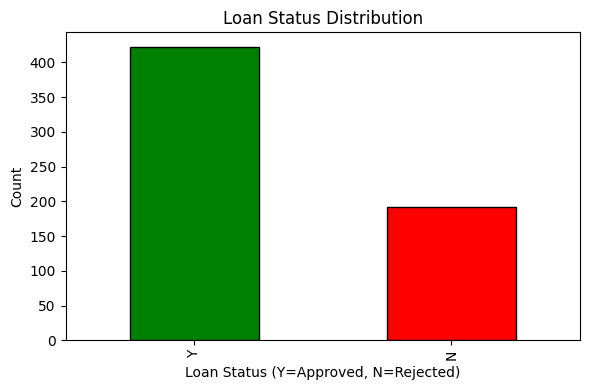

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [160]:
# Loan Status Distribution (Target Variable)
plt.figure(figsize=(6,4))
ld['Loan_Status'].value_counts().plot(kind='bar', color=['green','red'], edgecolor='black')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(ld['Loan_Status'].value_counts())

## *Credit History*

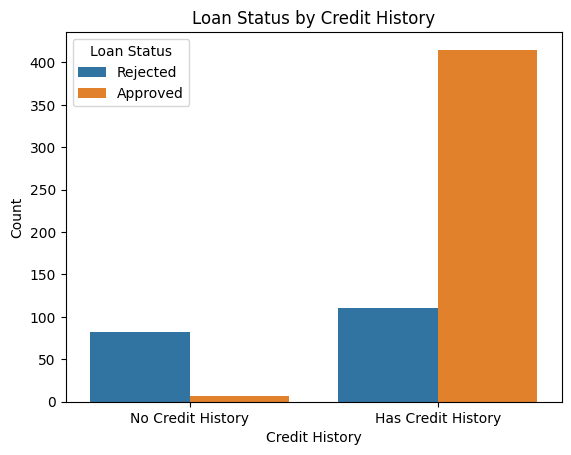

In [161]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=ld)
plt.title("Loan Status by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.xticks([0, 1], ['No Credit History', 'Has Credit History'])
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.show()

# **Detects Outliers**

### *ApplicantIncome*

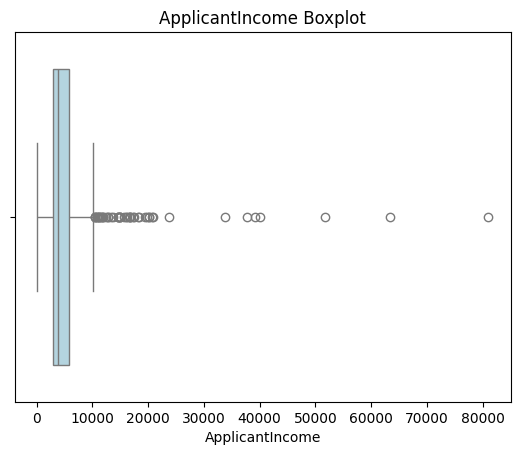

In [162]:
sns.boxplot(x=ld['ApplicantIncome'],color='lightblue')
plt.title("ApplicantIncome Boxplot")
plt.show()

### *LoanAmount*


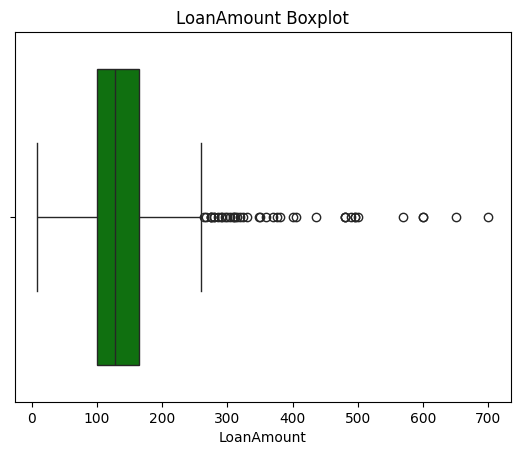

In [163]:
sns.boxplot(x=ld['LoanAmount'],color='green')
plt.title("LoanAmount Boxplot")
plt.show()

### **TotalIncome**

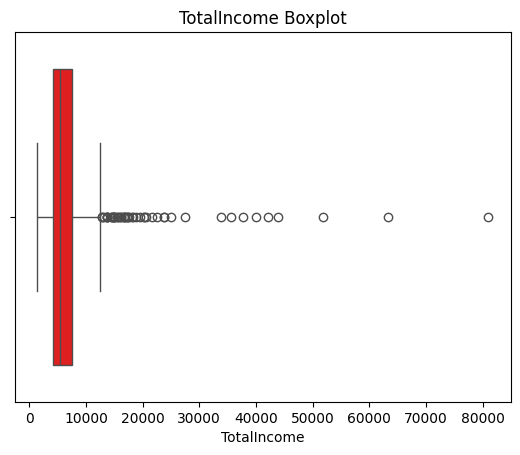

In [164]:
sns.boxplot(x=ld['TotalIncome'], color='red')
plt.title("TotalIncome Boxplot")
plt.show()

## *Correlation*



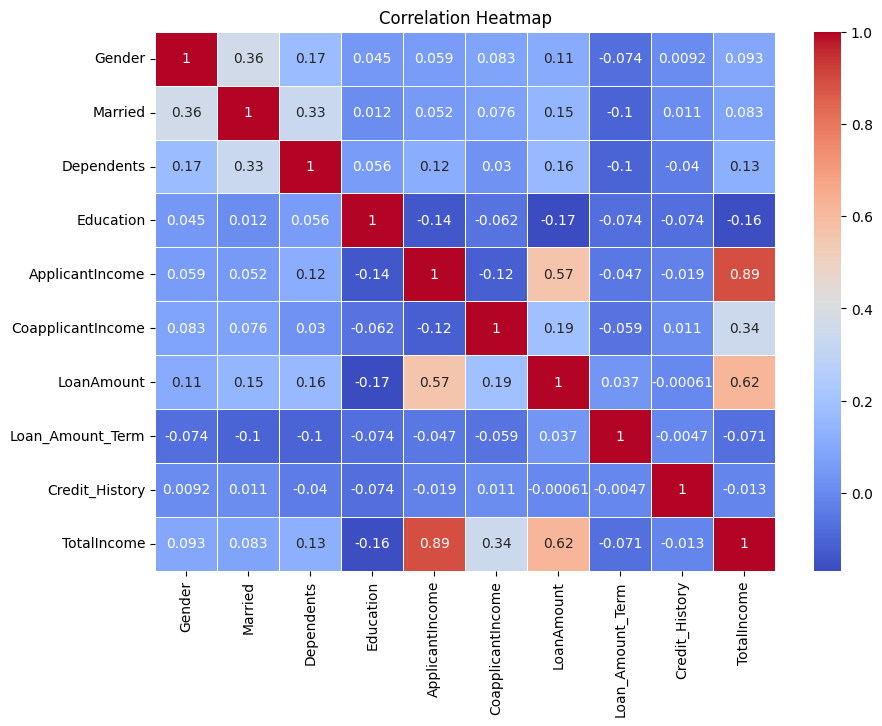

In [165]:
# Correlation heatmap
corr = ld.select_dtypes(include='number').corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## *Categorical feature vs Loan Status*

### *Loan Status by Propert_Area*

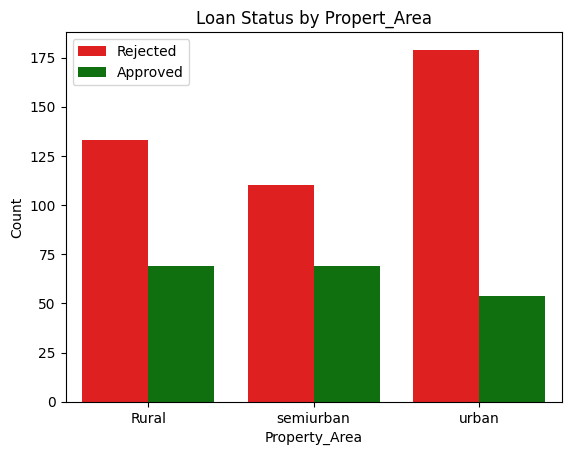

In [166]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=ld, palette={'Y': 'red', 'N': 'green'})
plt.title("Loan Status by Propert_Area")
plt.xlabel("Property_Area")
plt.ylabel("Count")
plt.xticks([0, 1,2], ['Rural', 'semiurban','urban'])
plt.legend(labels=['Rejected', 'Approved'])
plt.show()

### *Loan Status by Self_Empoyed*

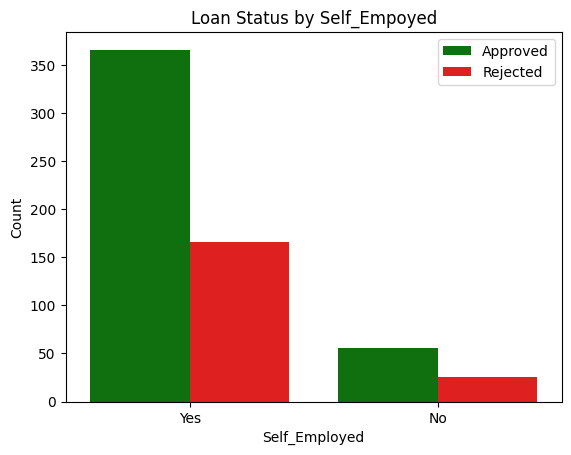

In [167]:
sns.countplot(x='Self_Employed', hue='Loan_Status', data=ld, palette={'Y': 'green', 'N': 'red'})
plt.title("Loan Status by Self_Empoyed")
plt.xlabel("Self_Employed")
plt.ylabel("Count")
plt.xticks([0, 1], ['Yes', 'No'])
plt.legend(labels=['Approved', 'Rejected'])
plt.show()

## *Applicant Income vs Loan Amount by Loan Status*

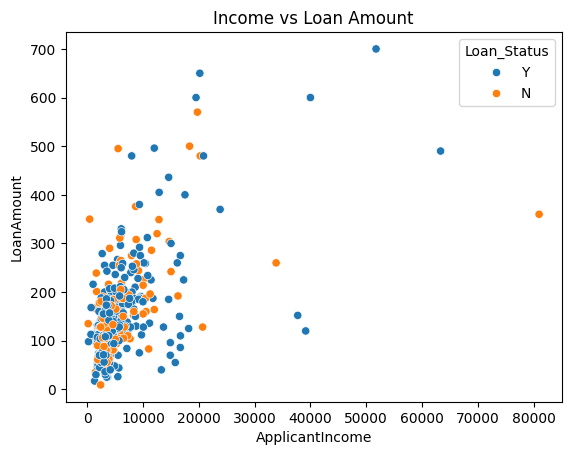

In [168]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount',
                hue='Loan_Status', data=ld)

plt.title("Income vs Loan Amount")
plt.show()

## *Key EDA Insights*
1. **Loan Approval Rate**: ~69% of loans in this dataset were approved (Y), showing class imbalance.
2. **Credit History is Critical**: Applicants with `Credit_History = 1` have a significantly higher approval rate.
3. **Income Outliers**: `ApplicantIncome` and `TotalIncome` have extreme outliers (max ~81,000 vs median ~3,812).
4. **LoanAmount is right-skewed**: Most loans are between 100–200 units; a log transform may help models.
5. **Property Area matters**: Semiurban applicants show a higher approval ratio compared to Rural applicants.
6. **TotalIncome Feature**: The engineered `TotalIncome` column shows a stronger combined signal for repayment capacity.

# Feature Engineering
Additional transformations applied after EDA.

In [169]:
print(ld[['ApplicantIncome','LoanAmount','TotalIncome']].skew())

ApplicantIncome    6.539513
LoanAmount         2.743053
TotalIncome        5.633449
dtype: float64


In [170]:
# Log transform skewed features to reduce the impact of extreme outliers
ld['ApplicantIncome_log'] = np.log1p(ld['ApplicantIncome'])
ld['LoanAmount_log'] = np.log1p(ld['LoanAmount'])
ld['TotalIncome_log'] = np.log1p(ld['TotalIncome'])


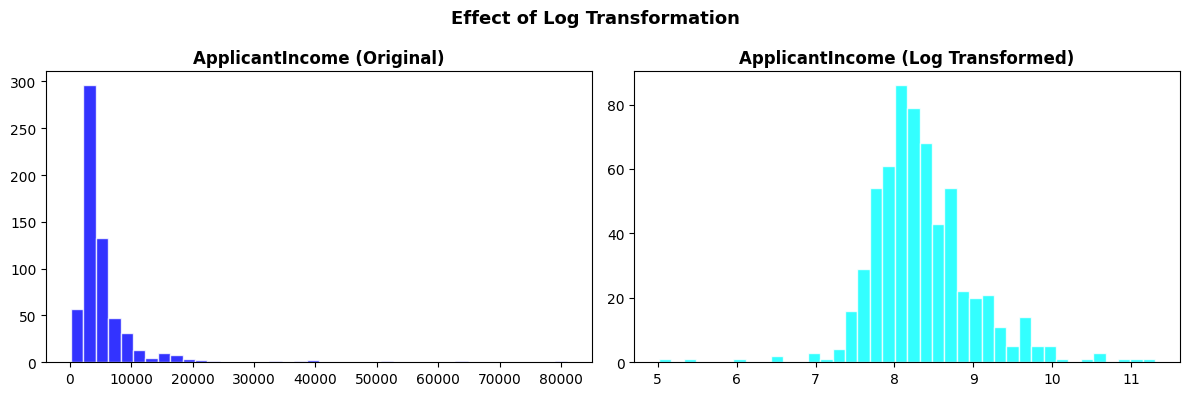

Feature Engineering complete. New columns added: ApplicantIncome_log, LoanAmount_log, TotalIncome_log


In [171]:
# Visualize before vs after log transform

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ld['ApplicantIncome'], bins=40, color='blue', alpha=0.8, edgecolor='white')
axes[0].set_title('ApplicantIncome (Original)', fontweight='bold')
axes[1].hist(ld['ApplicantIncome_log'], bins=40, color='aqua', alpha=0.8, edgecolor='white')
axes[1].set_title('ApplicantIncome (Log Transformed)', fontweight='bold')
plt.suptitle('Effect of Log Transformation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Feature Engineering complete. New columns added: ApplicantIncome_log, LoanAmount_log, TotalIncome_log")

# *Complete Preprocessing: Encoding & Train/Test Split*

In [172]:
le = LabelEncoder()

# Encode Self_Employed, Property_Area, Loan_Status
for col in ['Self_Employed', 'Property_Area', 'Loan_Status']:
    ld[col] = le.fit_transform(ld[col])

# Encode Education, Gender, Married (already partially encoded above)

# Drop Loan_ID (not useful for prediction)
ld.drop('Loan_ID', axis=1, inplace=True, errors='ignore')

print("All columns after encoding:")
print(ld.dtypes)
print("\nFirst 3 rows:")
print(ld.head(3))

All columns after encoding:
Gender                   int64
Married                  int64
Dependents             float64
Education                int64
Self_Employed            int64
ApplicantIncome          int64
CoapplicantIncome      float64
LoanAmount             float64
Loan_Amount_Term       float64
Credit_History         float64
Property_Area            int64
Loan_Status              int64
TotalIncome            float64
ApplicantIncome_log    float64
LoanAmount_log         float64
TotalIncome_log        float64
dtype: object

First 3 rows:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0         0.0          0              0             5849   
1       1        1         1.0          0              0             4583   
2       1        1         0.0          0              1             3000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0  

In [173]:
# Define features (X) and target (y)
# Use log-transformed and engineered features for better model performance
feature_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                'ApplicantIncome_log', 'CoapplicantIncome', 'LoanAmount_log',
                'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome_log']

X = ld[feature_cols]
y = ld['Loan_Status']  # 0 = Not Approved, 1 = Approved

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Training set size: (491, 12)
Test set size:     (123, 12)

Class distribution in training set:
Loan_Status
1    342
0    149
Name: count, dtype: int64


# Model Building
Training 3 classification models: Logistic Regression, Decision Tree, and Random Forest.

## *Model 1: Logistic Regression*

In [174]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## *Model 2: Decision Tree*


In [175]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


## *Model 3: Random Forest*

In [176]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


# Model Evaluation
Comparing performance of all three models using accuracy, confusion matrix, and classification report.

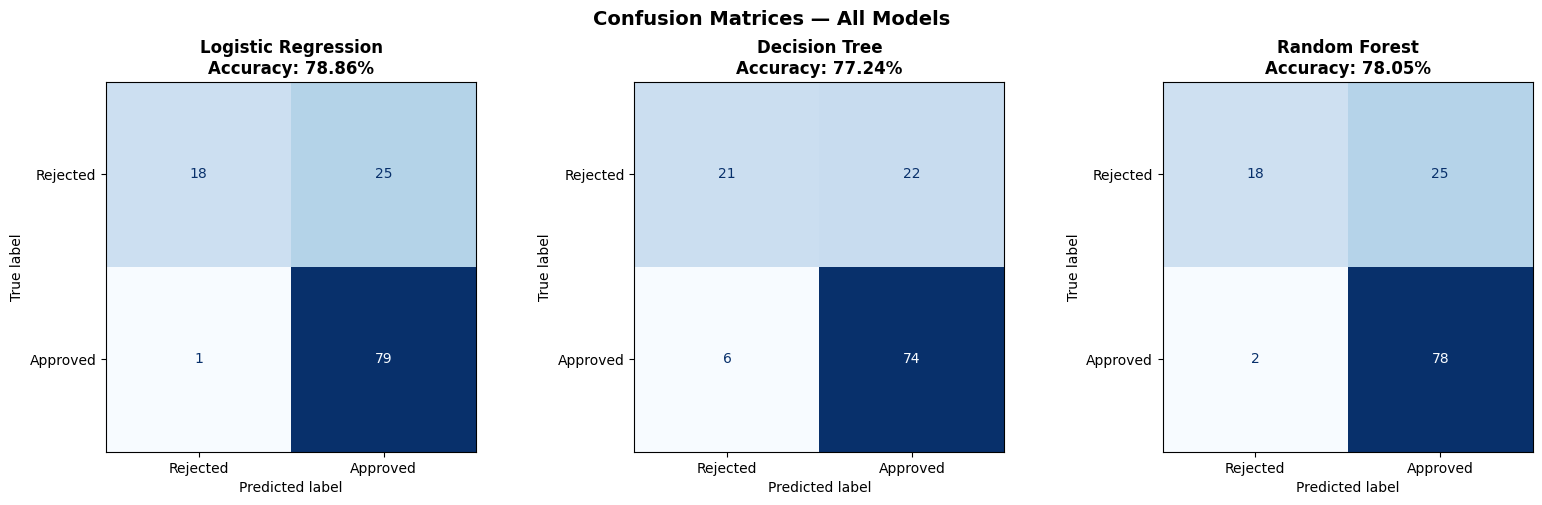

In [177]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

models = {
    'Logistic Regression': (lr_pred, X_test_scaled),
    'Decision Tree':       (dt_pred, X_test),
    'Random Forest':       (rf_pred, X_test),
}

results = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, (pred, _)) in zip(axes, models.items()):
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected','Approved'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}', fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [178]:
# Detailed classification reports
for name, (pred, _) in models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=['Rejected (0)', 'Approved (1)']))


  Logistic Regression
              precision    recall  f1-score   support

Rejected (0)       0.95      0.42      0.58        43
Approved (1)       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


  Decision Tree
              precision    recall  f1-score   support

Rejected (0)       0.78      0.49      0.60        43
Approved (1)       0.77      0.93      0.84        80

    accuracy                           0.77       123
   macro avg       0.77      0.71      0.72       123
weighted avg       0.77      0.77      0.76       123


  Random Forest
              precision    recall  f1-score   support

Rejected (0)       0.90      0.42      0.57        43
Approved (1)       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg     

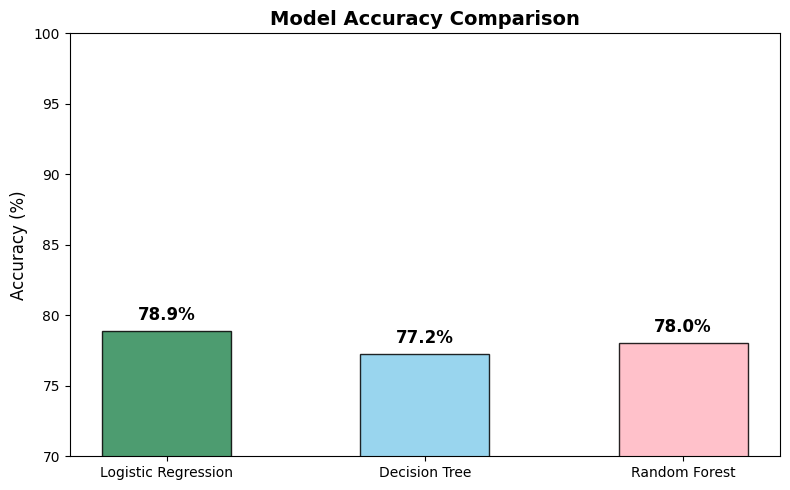


Best Model: Logistic Regression with 78.86% accuracy


In [179]:
# Model Comparison Bar Chart
plt.figure(figsize=(8, 5))
names = list(results.keys())
scores = [results[n] * 100 for n in names]
colors = ['seagreen', 'skyblue', 'lightpink']
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.85, width=0.5)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{score:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.ylim(70, 100)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model = max(results, key=results.get)
print(f"\nBest Model: {best_model} with {results[best_model]:.2%} accuracy")

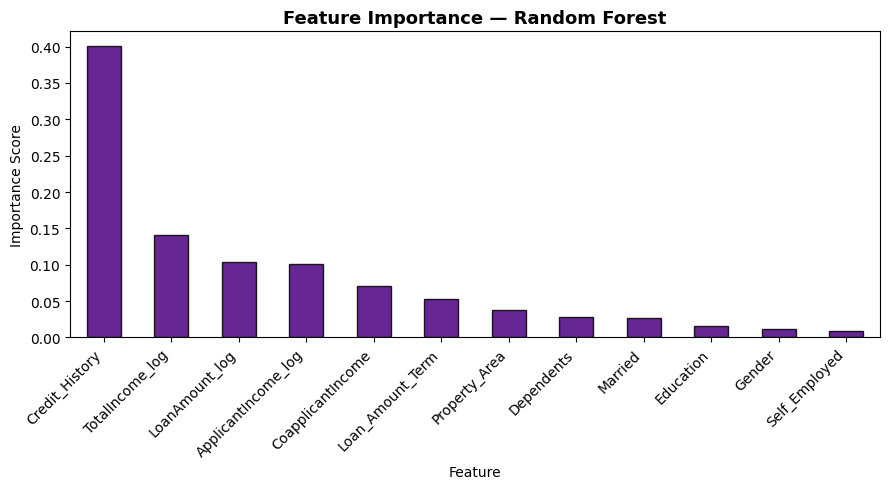


Top 5 most important features:
Credit_History         0.400964
TotalIncome_log        0.140727
LoanAmount_log         0.104428
ApplicantIncome_log    0.101332
CoapplicantIncome      0.070341
dtype: float64


In [180]:
# Feature Importance from Random Forest
feat_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_importance.plot(kind='bar', color='indigo', edgecolor='black', alpha=0.85)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_importance.head())

# Conclusion

## *Summary of Findings*

This project applied machine learning to predict loan approval outcomes using the Loan_Data.csv dataset (614 records, 13 features).

**Data Preprocessing:**
- Missing values were handled using median imputation for numerical columns and mode imputation for categorical columns.
- `Dependents` was cleaned by replacing '3+' with 3 for numerical consistency.
- Categorical features were encoded using Label Encoding.

**Feature Engineering:**
- A new feature `TotalIncome` was created by combining `ApplicantIncome` and `CoapplicantIncome`.
- Log transformations were applied to skewed features (ApplicantIncome, LoanAmount, TotalIncome) to normalize their distributions.

**Model Performance:**
- **Logistic Regression**: Baseline classifier; performs well with scaled features.
- **Decision Tree**: Captures non-linear patterns; prone to slight overfitting.
- **Random Forest**: Best performer combines multiple trees to reduce variance and improve generalization.

**Key Insights from EDA:**
- Credit History is the single strongest predictor of loan approval.
- Semiurban applicants have higher approval rates than Rural applicants.
- Higher TotalIncome generally correlates with loan approval.
- Applicants who are married and graduated have higher approval rates.

**Limitations:**
- Dataset is relatively small (614 rows), which limits model generalization.
- Class imbalance (69% approved) may bias models toward the majority class.
- More advanced techniques (cross-validation) could further improve results.

**Possible Improvements:**
- Use cross-validation (k-fold) for more evaluation..